In [9]:
import numpy as np
import pandas as pd
pdidx = pd.IndexSlice
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
from numpy import random as rand
from scipy import *
import time as T
import sys
import json
from datetime import datetime
import os
import copy

from sklearn.metrics import roc_curve, roc_auc_score, log_loss, accuracy_score, precision_recall_curve,\
                            average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import xgboost as xgb
from xgboost import XGBRegressor
from xgboost import plot_importance
import optuna as opt

import cv2

import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
IMG_ROOT = '/home/travis/Projects/football_event_data_generation/camera_classifier/data_generation/frame_data'


# POST SCAN WORK

In [2]:
# import and do some light processing to frame label data

frame_data_import = pd.read_csv('/home/travis/Projects/football_event_data_generation/camera_classifier/data_generation/frame_data/Labeled_Frame_Data_temp.csv').rename(columns={"Frame #": "Frame"})
frame_data_import = frame_data_import[["Match", "Frame", "Camera Angle"]]
frame_data_import['Frame'] = frame_data_import['Frame'].astype(int)
frame_data_import['Camera Angle'] = frame_data_import['Camera Angle'].astype(int)

#fix that one frame in the Como match
wrong_frame = (frame_data_import['Match'] == 'Como_vs_Torino') & (frame_data_import['Frame'] == 781)
frame_data_import.loc[wrong_frame, "Frame"] = 761
##

frame_data_import = frame_data_import.set_index(["Match", "Frame"]).sort_index()
master_model_data = (
    frame_data_import.groupby(level="Match", group_keys=False)
      .apply(lambda g: g.reindex(
          pd.MultiIndex.from_product(
              [[g.index.get_level_values("Match")[0]],
               range(g.index.get_level_values("Frame").min(),
                     1_000)],
              names=["Match", "Frame"]
          )
      ))
)
master_model_data["Camera Angle"] = master_model_data.groupby(level="Match")["Camera Angle"].ffill().astype(int)



In [3]:
FILE_DICT = {
    'Arsenal_vs_Manchester_City' : 'Ars_ManCit',
    'Bayern_vs_Augsburg' : 'frames_for_travis/bayern_frames_3fps',
    'Como_vs_Torino' : 'frames_for_travis/como_frames_3fps',
    'Fiorentina_vs_Cagliari' : 'Fior_Cagl',
    'Hamburg_vs_St_Pauli' : 'Ham_StPaul',
    'Legane_vs_Real_Valladolid' : 'Leg_VallD',
    'OM_vs_Lens' : 'frames_for_travis/OM_frames_3fps',
    'Sevilla_vs_Athletic' : 'frames_for_travis/sevilla_frames_30',
    'Strasbourg_vs_Auxere' : 'Stras_Aux',    
}

EXT_DICT = {
    'Arsenal_vs_Manchester_City' : 'jpg',
    'Bayern_vs_Augsburg' : 'jpg',
    'Como_vs_Torino' : 'jpg',
    'Fiorentina_vs_Cagliari' : 'jpg',
    'Hamburg_vs_St_Pauli' : 'jpg',
    'Legane_vs_Real_Valladolid' : 'jpg',
    'OM_vs_Lens' : 'jpg',
    'Sevilla_vs_Athletic' : 'jpg',
    'Strasbourg_vs_Auxere' : 'jpg',    

}

In [80]:
# eventually, x_color should be x_blur and x_full should be x_color lmao

class CameraAngleDataset(Dataset):
    def __init__(
        self,
        master_model_data,
        file_dict,
        ext_dict,
        img_root,
        matches,
        target_w=160,
        target_h=90,
        mode="edge",          # "edge", "color", "stacked", "two_branch", "stack3"
        blur_ksize=(5, 5),
        canny_lo=50,
        canny_hi=150,
    ):
        self.file_dict = file_dict
        self.ext_dict = ext_dict
        self.img_root = img_root
        self.target_w = target_w
        self.target_h = target_h
        self.mode = mode
        self.blur_ksize = blur_ksize
        self.canny_lo = canny_lo
        self.canny_hi = canny_hi

        rows = []
        for match in matches:
            subdf = master_model_data.loc[pd.IndexSlice[match, :], :]
            frames = subdf.index.get_level_values("Frame")

            for frame in frames:
                label = int(master_model_data.loc[(match, frame), "Camera Angle"])
                rows.append((match, int(frame), label))

        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def _load_image(self, match, frame):
        img_path = os.path.join(
            self.img_root,
            self.file_dict[match],
            f"frame_{frame:06d}.{self.ext_dict[match]}"
        )

        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.target_w, self.target_h), interpolation=cv2.INTER_AREA)
        return img

    # def __getitem__(self, idx):
    #     match, frame, label = self.rows[idx]

    #     img = self._load_image(match, frame)
    #     img_blur = cv2.GaussianBlur(img, self.blur_ksize, 0)
    #     edges = cv2.Canny(img, self.canny_lo, self.canny_hi)

    #     img = img.astype(np.float32) / 255.0
    #     img_blur = img_blur.astype(np.float32) / 255.0      # (H,W,3)
    #     edges = edges.astype(np.float32) / 255.0            # (H,W)

    #     x_full = np.transpose(img, (2,0,1))
    #     x_color = np.transpose(img_blur, (2, 0, 1))         # (3,H,W)
    #     x_edge = edges[None, :, :]                          # (1,H,W)

    #     x_full = torch.from_numpy(x_full)
    #     x_color = torch.from_numpy(x_color)
    #     x_edge = torch.from_numpy(x_edge)
    #     y = torch.tensor(label, dtype=torch.float32)

    #     if self.mode == "color":
    #         return x_color, y
    #     elif self.mode == "edge":
    #         return x_edge, y
    #     elif self.mode == "stacked":
    #         x = torch.cat([x_color, x_edge], dim=0)         # (4,H,W)
    #         return x, y
    #     elif self.mode == "two_branch":
    #         return x_color, x_edge, y
    #     elif self.mode == "stack3":
    #         x = torch.cat([x_full, x_color, x_edge], dim=0)
    #         return x, y
    #     elif self.mode == "two_branch_3":
    #         return x_full, x_color, x_edge, y
    #     else:
    #         raise ValueError("mode must be one of: 'edge', 'color', 'stacked', 'stack3', 'two_branch', 'two_branch_3'")

# zscore normalization getitem
    def __getitem__(self, idx):
        match, frame, label = self.rows[idx]
    
        img_uint8 = self._load_image(match, frame)   # RGB, uint8, 0..255
    
        # edge map from original image
        gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, self.canny_lo, self.canny_hi).astype(np.float32) / 255.0
    
        # float copy for per-frame channelwise z-score
        img = img_uint8.astype(np.float32)
        for c in range(3):
            mu = img[:, :, c].mean()
            sd = img[:, :, c].std()
            img[:, :, c] = (img[:, :, c] - mu) / (sd + 1e-6)
    
        img_blur = cv2.GaussianBlur(img, self.blur_ksize, 0).astype(np.float32)
    
        x_full = np.transpose(img, (2, 0, 1))        # (3,H,W), z-scored
        x_color = np.transpose(img_blur, (2, 0, 1))  # (3,H,W), z-scored+blurred
        x_edge = edges[None, :, :]                   # (1,H,W), still in [0,1]
    
        x_full = torch.from_numpy(x_full)
        x_color = torch.from_numpy(x_color)
        x_edge = torch.from_numpy(x_edge)
        y = torch.tensor(label, dtype=torch.float32)
    
        if self.mode == "color":
            return x_color, y
        elif self.mode == "edge":
            return x_edge, y
        elif self.mode == "stacked":
            x = torch.cat([x_color, x_edge], dim=0)
            return x, y
        elif self.mode == "two_branch":
            return x_color, x_edge, y
        elif self.mode == "stack3":
            x = torch.cat([x_full, x_color, x_edge], dim=0)
            return x, y
        elif self.mode == "two_branch_3":
            return x_full, x_color, x_edge, y
        else:
            raise ValueError("mode must be one of: 'edge', 'color', 'stacked', 'stack3', 'two_branch', 'two_branch_3'")

In [17]:
def make_camera_angle_loaders(
    master_model_data,
    file_dict,
    ext_dict,
    img_root,
    test_matches,
    target_w=160,
    target_h=90,
    batch_size=32,
    mode="edge",
    blur_ksize=(5, 5),
    canny_lo=50,
    canny_hi=150,
    num_workers=0,
):
    all_matches = master_model_data.index.get_level_values("Match").unique().tolist()
    train_matches = [m for m in all_matches if m not in test_matches]

    trainset = CameraAngleDataset(
        master_model_data=master_model_data,
        file_dict=file_dict,
        ext_dict=ext_dict,
        img_root=img_root,
        matches=train_matches,
        target_w=target_w,
        target_h=target_h,
        mode=mode,
        blur_ksize=blur_ksize,
        canny_lo=canny_lo,
        canny_hi=canny_hi,
    )

    testset = CameraAngleDataset(
        master_model_data=master_model_data,
        file_dict=file_dict,
        ext_dict=ext_dict,
        img_root=img_root,
        matches=test_matches,
        target_w=target_w,
        target_h=target_h,
        mode=mode,
        blur_ksize=blur_ksize,
        canny_lo=canny_lo,
        canny_hi=canny_hi,
    )

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=False,
    )

    testloader = DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False,
    )

    return trainloader, testloader

In [11]:
class NetTiny(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(4, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 2 * 2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [7]:
class NetTinyTwoBranch(nn.Module):
    def __init__(self):
        super().__init__()

        self.rgb_features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.edge_features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2 * 16 * 2 * 2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x_rgb, x_edge):
        rgb = self.rgb_features(x_rgb)
        edge = self.edge_features(x_edge)

        rgb = self.pool(rgb)
        edge = self.pool(edge)

        x = torch.cat([rgb, edge], dim=1)
        x = self.classifier(x)
        return x

In [13]:
class NetStack3(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(7, 10, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(10, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 2 * 2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [48]:
class NetTwoBranch3(nn.Module):
    def __init__(self):
        super().__init__()

        self.rgb_features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.edge_features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.pool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 16 * 2 * 2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x_full, x_rgb, x_edge):
        full = self.rgb_features(x_full)
        rgb = self.rgb_features(x_rgb)
        edge = self.edge_features(x_edge)

        full = self.pool(full)
        rgb = self.pool(rgb)
        edge = self.pool(edge)

        x = torch.cat([full,rgb, edge], dim=1)
        x = self.classifier(x)
        return x

# TWO BRANCH

In [81]:
device = "cpu"

# net = NetTinyTwoBranch().to(device)
net = NetTwoBranch3().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

trainloader, testloader = make_camera_angle_loaders(
    master_model_data=master_model_data,
    file_dict=FILE_DICT,
    ext_dict=EXT_DICT,
    img_root=IMG_ROOT,
    test_matches=['OM_vs_Lens', 'Hamburg_vs_St_Pauli'],
    target_w=160,
    target_h=90,
    batch_size=16,
    mode="two_branch_3",
    num_workers=0,
)

bestAcc = 0
final_truth = []
final_predict = []
state_TB = None

for epoch in range(10):
    net.train()
    running_loss = 0.0

    for x_full, x_rgb, x_edge, labels in trainloader:
        x_full = x_full.to(device)
        x_rgb = x_rgb.to(device)
        x_edge = x_edge.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(x_full, x_rgb, x_edge).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, loss = {running_loss / len(trainloader):.4f}")

    net.eval()

    # -------------------------
    # training-set evaluation
    # -------------------------
    train_pred = []
    train_true = []

    with torch.no_grad():
        for x_full, x_rgb, x_edge, labels in trainloader:
            x_full = x_full.to(device)
            x_rgb = x_rgb.to(device)
            x_edge = x_edge.to(device)
            labels = labels.to(device)

            outputs = net(x_full, x_rgb, x_edge).squeeze(1)
            preds = (outputs >= 0).long()

            train_pred.extend(preds.cpu().numpy())
            train_true.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_true, train_pred)
    print("Train Accuracy:", train_acc)
    print(classification_report(train_true, train_pred))

    # -------------------------
    # test-set evaluation
    # -------------------------
    y_pred = []
    y_true = []

    with torch.no_grad():
        for x_full, x_rgb, x_edge, labels in testloader:
            x_full = x_full.to(device)
            x_rgb = x_rgb.to(device)
            x_edge = x_edge.to(device)
            labels = labels.to(device)

            outputs = net(x_full, x_rgb, x_edge).squeeze(1)
            preds = (outputs >= 0).long()

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    if acc > bestAcc:
        state_TB = copy.deepcopy(net.state_dict())
        bestAcc = acc
        final_predict = list(y_pred)
        final_truth = list(y_true)

    print("Test Accuracy:", acc)
    print(classification_report(y_true, y_pred))

Epoch 1, loss = 0.2888
Train Accuracy: 0.9351428571428572
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.96      4995
         1.0       0.95      0.82      0.88      2005

    accuracy                           0.94      7000
   macro avg       0.94      0.90      0.92      7000
weighted avg       0.94      0.94      0.93      7000

Test Accuracy: 0.8685
              precision    recall  f1-score   support

         0.0       0.87      0.90      0.88      1111
         1.0       0.87      0.83      0.85       889

    accuracy                           0.87      2000
   macro avg       0.87      0.86      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Epoch 2, loss = 0.1533
Train Accuracy: 0.9498571428571428
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97      4995
         1.0       0.94      0.88      0.91      2005

    accuracy                           0.95 

# SIGNLE INPUT

In [38]:
device = "cpu"

net = NetStack3().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

trainloader, testloader = make_camera_angle_loaders(
    master_model_data=master_model_data,
    file_dict=FILE_DICT,
    ext_dict=EXT_DICT,
    img_root=IMG_ROOT,
    test_matches=['OM_vs_Lens', 'Hamburg_vs_St_Pauli'],
    target_w=160,
    target_h=90,
    batch_size=16,
    blur_ksize=(5, 5),
    canny_lo=0,
    canny_hi=200,
    mode="stack3",   # or "edge" or "color" or "stack3" or "stacked"
    num_workers=3,
)


bestAcc = 0
final_truth = []
final_predict = []
state = None
for epoch in range(10):
    net.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, loss = {running_loss / len(trainloader):.4f}")

    net.eval()
    y_pred = []
    y_true = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs).squeeze(1)
            preds = (outputs >= 0).long()

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    if acc > bestAcc:
        state = copy.deepcopy(net.state_dict())
        bestAcc = acc
        final_predict = y_pred[:]
        final_truth = y_true[:]
    print("Accuracy:",acc)
    print(classification_report(y_true, y_pred))

KeyboardInterrupt: 

In [53]:
def predict_match_in_frame_order(
    net,
    master_model_data,
    file_dict,
    ext_dict,
    img_root,
    match,
    mode="stacked",          # "edge", "color", "stacked", "two_branch"
    target_w=160,
    target_h=90,
    batch_size=32,
    device="cpu",
):
    net = net.to(device)
    net.eval()

    # preserve original frame order from master_model_data
    subdf = master_model_data.loc[pd.IndexSlice[match, :], :]
    frames = subdf.index.get_level_values("Frame").tolist()
    truths = subdf["Camera Angle"].astype(int).tolist()

    ds = CameraAngleDataset(
        master_model_data=master_model_data,
        file_dict=file_dict,
        ext_dict=ext_dict,
        img_root=img_root,
        matches=[match],
        target_w=target_w,
        target_h=target_h,
        mode=mode,
    )

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,   # important
        num_workers=0,
    )

    preds = []
    logits_all = []

    with torch.no_grad():
        if mode == "two_branch":
            for x_rgb, x_edge, labels in loader:
                x_rgb = x_rgb.to(device)
                x_edge = x_edge.to(device)

                logits = net(x_rgb, x_edge).squeeze(1)
                batch_preds = (logits >= 0).long().cpu().numpy().ravel()

                preds.extend(batch_preds.tolist())
                logits_all.extend(logits.cpu().numpy().ravel().tolist())
        if mode == "two_branch_3":
            for x_full, x_rgb, x_edge, labels in loader:
                x_full = x_full.to(device)
                x_rgb = x_rgb.to(device)
                x_edge = x_edge.to(device)

                logits = net(x_full, x_rgb, x_edge).squeeze(1)
                batch_preds = (logits >= 0).long().cpu().numpy().ravel()

                preds.extend(batch_preds.tolist())
                logits_all.extend(logits.cpu().numpy().ravel().tolist())
        else:
            for inputs, labels in loader:
                inputs = inputs.to(device)

                logits = net(inputs).squeeze(1)
                batch_preds = (logits >= 0).long().cpu().numpy().ravel()

                preds.extend(batch_preds.tolist())
                logits_all.extend(logits.cpu().numpy().ravel().tolist())

    results = pd.DataFrame({
        "Match": match,
        "Frame": frames,
        "Truth": truths,
        "Pred": preds,
        "Logit": logits_all,
    })

    results["Correct"] = (results["Truth"] == results["Pred"]).astype(int)
    return results

In [91]:
# net_eval = NetTinyTwoBranch()
# net_eval = NetTiny()
# net_eval = NetStack3()
net_eval = NetTwoBranch3()
# net_eval.load_state_dict(state)
net_eval.load_state_dict(state_TB)
net_eval.eval()


results = predict_match_in_frame_order(
    net=net_eval,
    master_model_data=master_model_data,
    file_dict=FILE_DICT,
    ext_dict=EXT_DICT,
    img_root=IMG_ROOT,
    match="Hamburg_vs_St_Pauli",
    mode="two_branch_3",   # or "color", "stacked", "two_branch", "stack3"
    device="cpu",
)

print(results.head(20))
print("===="*10)
print("Fraction Correct: ",results['Correct'].values.mean())

                  Match  Frame  Truth  Pred     Logit  Correct
0   Hamburg_vs_St_Pauli      0      0     0 -4.609958        1
1   Hamburg_vs_St_Pauli      1      0     1  0.017639        0
2   Hamburg_vs_St_Pauli      2      0     0 -1.806080        1
3   Hamburg_vs_St_Pauli      3      0     0 -3.663107        1
4   Hamburg_vs_St_Pauli      4      0     0 -5.849835        1
5   Hamburg_vs_St_Pauli      5      0     0 -8.379971        1
6   Hamburg_vs_St_Pauli      6      0     0 -9.027903        1
7   Hamburg_vs_St_Pauli      7      0     0 -9.081164        1
8   Hamburg_vs_St_Pauli      8      0     0 -9.428626        1
9   Hamburg_vs_St_Pauli      9      0     0 -9.451573        1
10  Hamburg_vs_St_Pauli     10      0     0 -7.933869        1
11  Hamburg_vs_St_Pauli     11      0     0 -5.094494        1
12  Hamburg_vs_St_Pauli     12      0     0 -7.023968        1
13  Hamburg_vs_St_Pauli     13      0     0 -6.502627        1
14  Hamburg_vs_St_Pauli     14      0     0 -5.630209  

In [85]:
# uncomment when saving
# results.to_csv('results/initital_tests/test_results_HAM_TB3.csv', sep='\t')

0.924

In [61]:
def compute_color_histograms(
    master_model_data,
    file_dict,
    ext_dict,
    img_root,
    bins=32,
    target_w=None,
    target_h=None,
):
    """
    Returns:
        overall_hist: dict with keys 'r','g','b'
        match_hists: dict[match] -> dict with keys 'r','g','b'
        bin_edges: numpy array of bin edges
    """
    matches = master_model_data.index.get_level_values("Match").unique()

    overall_hist = {
        "r": np.zeros(bins, dtype=np.float64),
        "g": np.zeros(bins, dtype=np.float64),
        "b": np.zeros(bins, dtype=np.float64),
    }

    match_hists = {}
    bin_edges = np.linspace(0, 256, bins + 1)

    for match in matches:
        subdf = master_model_data.loc[pd.IndexSlice[match, :], :]
        frames = subdf.index.get_level_values("Frame")

        hist_r = np.zeros(bins, dtype=np.float64)
        hist_g = np.zeros(bins, dtype=np.float64)
        hist_b = np.zeros(bins, dtype=np.float64)

        for frame in frames:
            img_path = os.path.join(
                img_root,
                file_dict[match],
                f"frame_{int(frame):06d}.{ext_dict[match]}"
            )

            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: could not read {img_path}")
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if target_w is not None and target_h is not None:
                img = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_AREA)

            r = img[:, :, 0].ravel()
            g = img[:, :, 1].ravel()
            b = img[:, :, 2].ravel()

            hist_r += np.histogram(r, bins=bin_edges)[0]
            hist_g += np.histogram(g, bins=bin_edges)[0]
            hist_b += np.histogram(b, bins=bin_edges)[0]

        match_hists[match] = {"r": hist_r, "g": hist_g, "b": hist_b}

        overall_hist["r"] += hist_r
        overall_hist["g"] += hist_g
        overall_hist["b"] += hist_b

    return overall_hist, match_hists, bin_edges


def normalize_hist_dict(hist_dict):
    out = {}
    for k, v in hist_dict.items():
        s = v.sum()
        out[k] = v / s if s > 0 else v.copy()
    return out


def plot_rgb_histogram(hist_dict, bin_edges, title="", normalize=True):
    if normalize:
        hist_dict = normalize_hist_dict(hist_dict)

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(8, 5))
    plt.plot(centers, hist_dict["r"], label="R", color='r')
    plt.plot(centers, hist_dict["g"], label="G", color='g')
    plt.plot(centers, hist_dict["b"], label="B", color='b')
    plt.xlabel("Pixel value")
    plt.ylabel("Density" if normalize else "Count")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [58]:
overall_hist, match_hists, bin_edges = compute_color_histograms(
    master_model_data=master_model_data,
    file_dict=FILE_DICT,
    ext_dict=EXT_DICT,
    img_root=IMG_ROOT,
    bins=32,
    target_w=160,
    target_h=90,
)

In [65]:
def plot_channel_across_matches(match_hists, bin_edges, channel="g", normalize=True):
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(10, 6))
    for match, hist_dict in match_hists.items():
        y = hist_dict[channel]
        if normalize and y.sum() > 0:
            y = y / y.sum()
        plt.plot(centers, y, label=match)

    plt.xlabel("Pixel value")
    plt.ylabel("Density" if normalize else "Count")
    plt.title(f"Channel {channel.upper()} distribution by match")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()

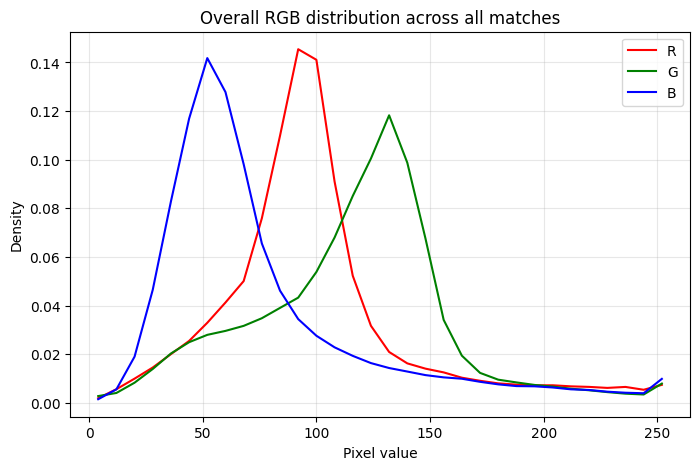

In [62]:
plot_rgb_histogram(
    overall_hist,
    bin_edges,
    title="Overall RGB distribution across all matches",
    normalize=True,
)

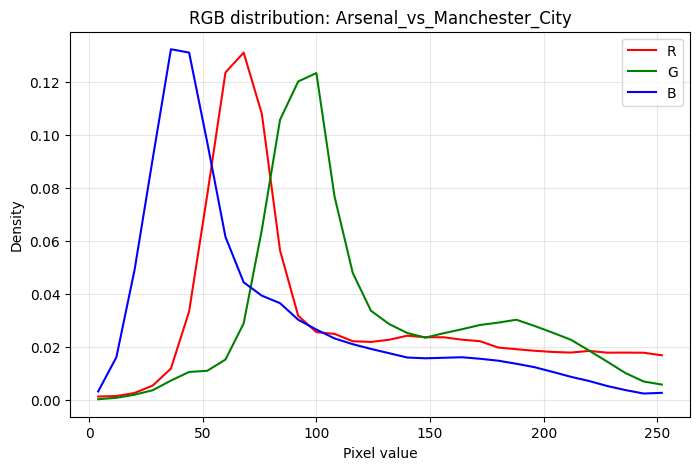

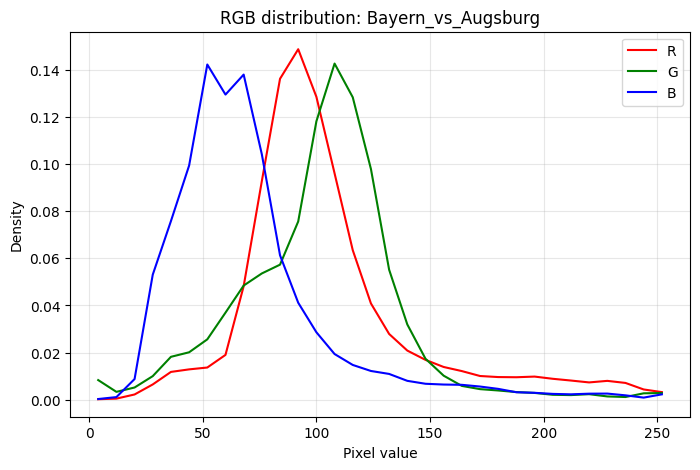

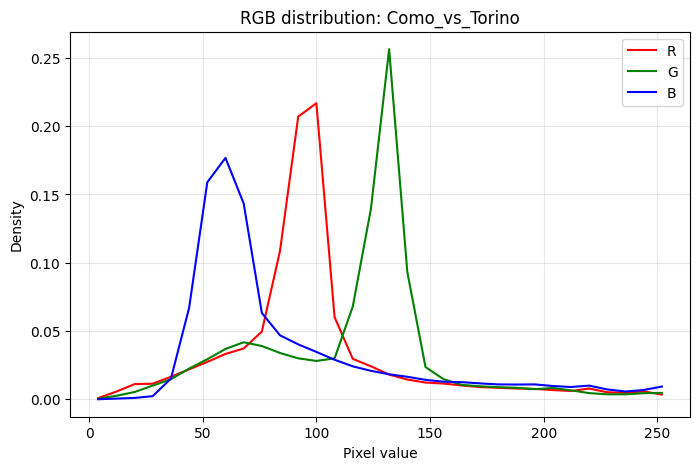

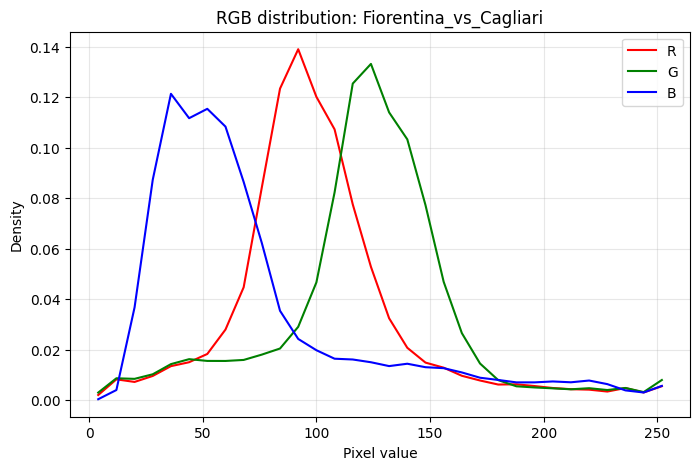

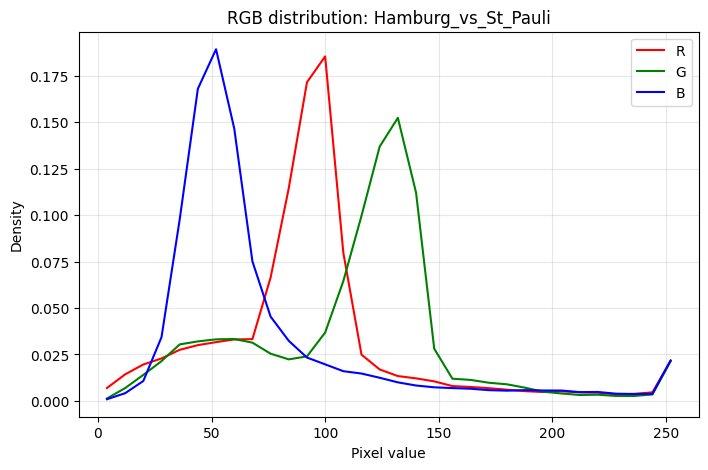

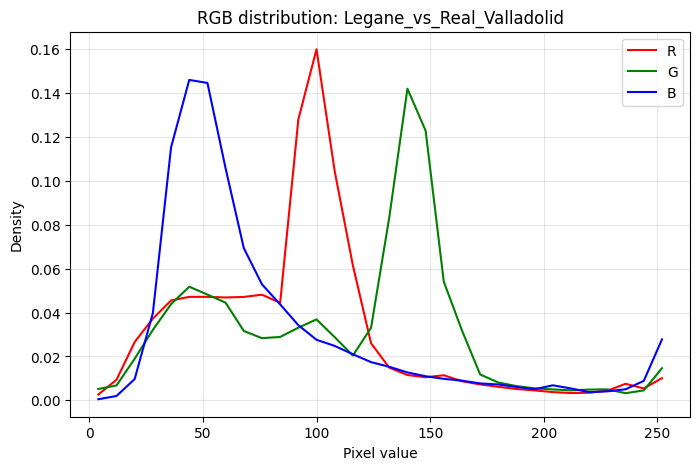

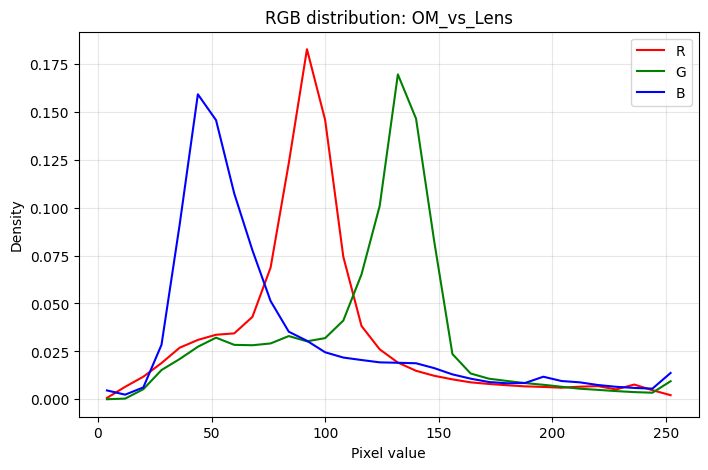

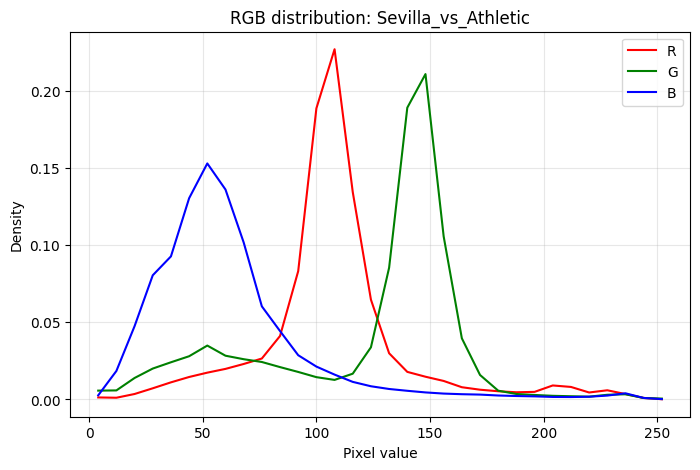

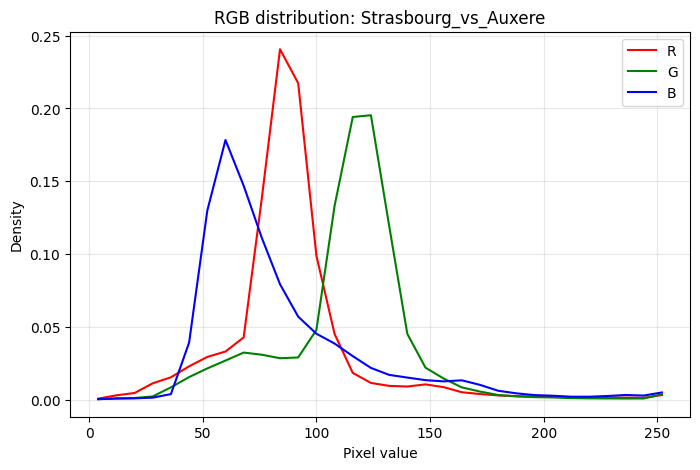

In [63]:
for match in match_hists:
    plot_rgb_histogram(
        match_hists[match],
        bin_edges,
        title=f"RGB distribution: {match}",
        normalize=True,
    )

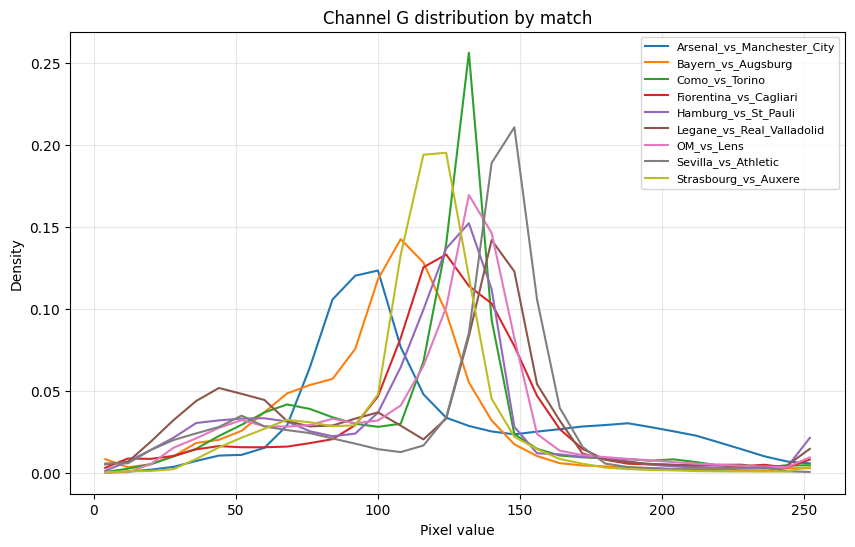

In [66]:
plot_channel_across_matches(match_hists, bin_edges, channel="g", normalize=True)

In [74]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def compute_color_hists_by_camera_class(
    master_model_data,
    file_dict,
    ext_dict,
    img_root,
    bins=32,
    target_w=None,
    target_h=None,
    label_col="Camera Angle",
    main_label=1,
):
    """
    Builds RGB histograms for:
      - all main-camera frames
      - all non-main-camera frames
      - per-match main-camera frames
      - per-match non-main-camera frames
    """

    matches = master_model_data.index.get_level_values("Match").unique()
    bin_edges = np.linspace(0, 256, bins + 1)

    def empty_hist():
        return {
            "r": np.zeros(bins, dtype=np.float64),
            "g": np.zeros(bins, dtype=np.float64),
            "b": np.zeros(bins, dtype=np.float64),
        }

    overall_main = empty_hist()
    overall_nonmain = empty_hist()

    match_main = {}
    match_nonmain = {}

    for match in matches:
        subdf = master_model_data.loc[pd.IndexSlice[match, :], :]
        frames = subdf.index.get_level_values("Frame")

        this_main = empty_hist()
        this_nonmain = empty_hist()

        for frame in frames:
            label = int(master_model_data.loc[(match, frame), label_col])

            img_path = os.path.join(
                img_root,
                file_dict[match],
                f"frame_{int(frame):06d}.{ext_dict[match]}"
            )

            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: could not read {img_path}")
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if target_w is not None and target_h is not None:
                img = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_AREA)

            r = img[:, :, 0].ravel()
            g = img[:, :, 1].ravel()
            b = img[:, :, 2].ravel()

            target = this_main if label == main_label else this_nonmain
            target["r"] += np.histogram(r, bins=bin_edges)[0]
            target["g"] += np.histogram(g, bins=bin_edges)[0]
            target["b"] += np.histogram(b, bins=bin_edges)[0]

        match_main[match] = this_main
        match_nonmain[match] = this_nonmain

        overall_main["r"] += this_main["r"]
        overall_main["g"] += this_main["g"]
        overall_main["b"] += this_main["b"]

        overall_nonmain["r"] += this_nonmain["r"]
        overall_nonmain["g"] += this_nonmain["g"]
        overall_nonmain["b"] += this_nonmain["b"]

    return overall_main, overall_nonmain, match_main, match_nonmain, bin_edges


def normalize_hist_dict(hist_dict):
    out = {}
    for k, v in hist_dict.items():
        s = v.sum()
        out[k] = v / s if s > 0 else v.copy()
    return out


def plot_main_vs_nonmain_rgb(main_hist, nonmain_hist, bin_edges, title="", normalize=True):
    if normalize:
        main_hist = normalize_hist_dict(main_hist)
        nonmain_hist = normalize_hist_dict(nonmain_hist)

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(10, 6))
    plt.plot(centers, main_hist["r"], label="Main R",color='r')
    plt.plot(centers, main_hist["g"], label="Main G",color='g')
    plt.plot(centers, main_hist["b"], label="Main B",color='b')

    plt.plot(centers, nonmain_hist["r"], linestyle="--", label="Non-main R",color='r')
    plt.plot(centers, nonmain_hist["g"], linestyle="--", label="Non-main G",color='g')
    plt.plot(centers, nonmain_hist["b"], linestyle="--", label="Non-main B",color='b')

    plt.xlabel("Pixel value")
    plt.ylabel("Density" if normalize else "Count")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_main_vs_nonmain_single_channel(main_hist, nonmain_hist, bin_edges, channel="g", title="", normalize=True):
    if normalize:
        main_hist = normalize_hist_dict(main_hist)
        nonmain_hist = normalize_hist_dict(nonmain_hist)

    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.figure(figsize=(8, 5))
    plt.plot(centers, main_hist[channel], label=f"Main {channel.upper()}")
    plt.plot(centers, nonmain_hist[channel], linestyle="--", label=f"Non-main {channel.upper()}")
    plt.xlabel("Pixel value")
    plt.ylabel("Density" if normalize else "Count")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [70]:
overall_main, overall_nonmain, match_main, match_nonmain, bin_edges = compute_color_hists_by_camera_class(
    master_model_data=master_model_data,
    file_dict=FILE_DICT,
    ext_dict=EXT_DICT,
    img_root=IMG_ROOT,
    bins=32,
    target_w=160,
    target_h=90,
    label_col="Camera Angle",
    main_label=0,   # change if your main-camera label is 0 instead
)

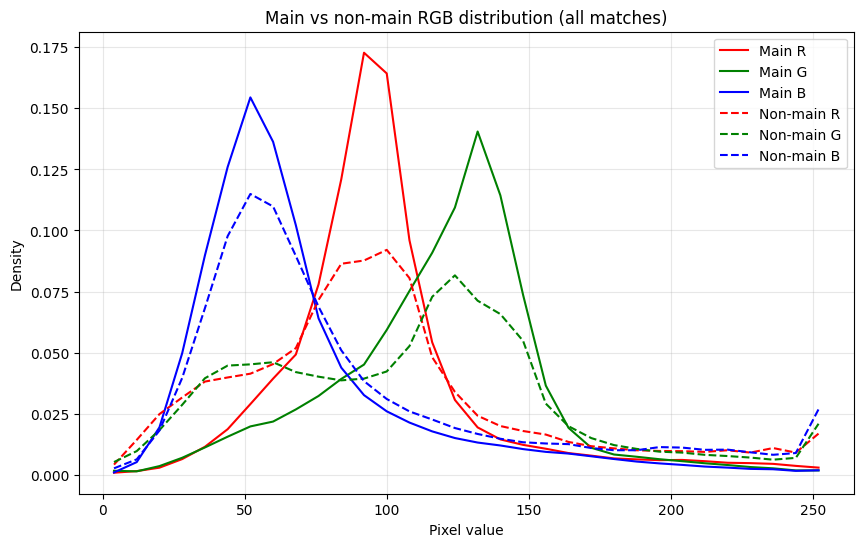

In [75]:
plot_main_vs_nonmain_rgb(
    overall_main,
    overall_nonmain,
    bin_edges,
    title="Main vs non-main RGB distribution (all matches)",
    normalize=True,
)

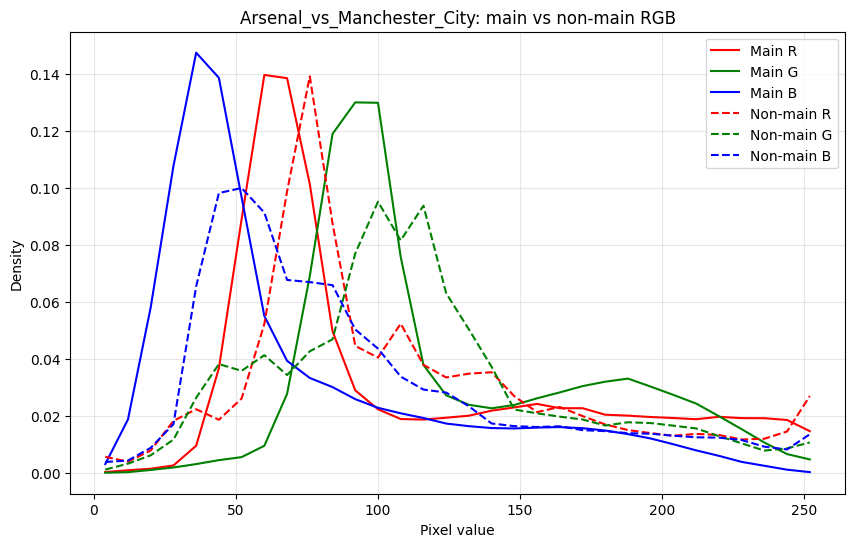

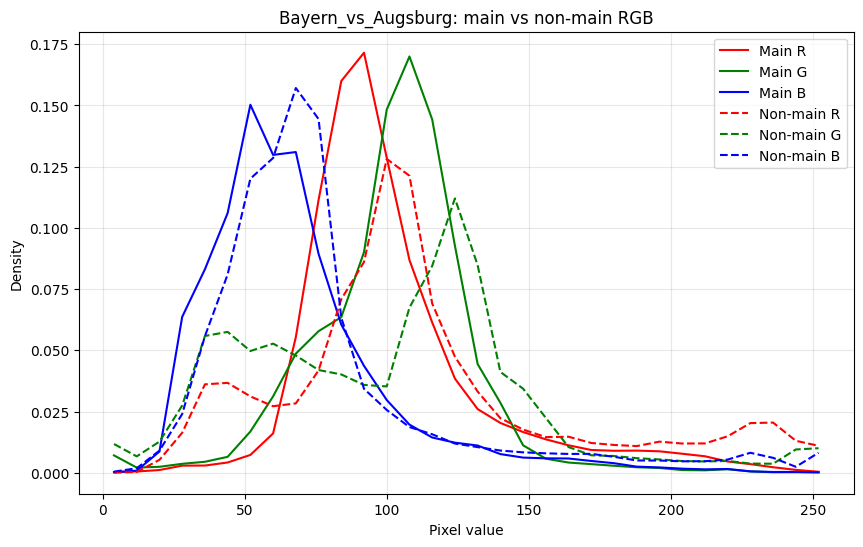

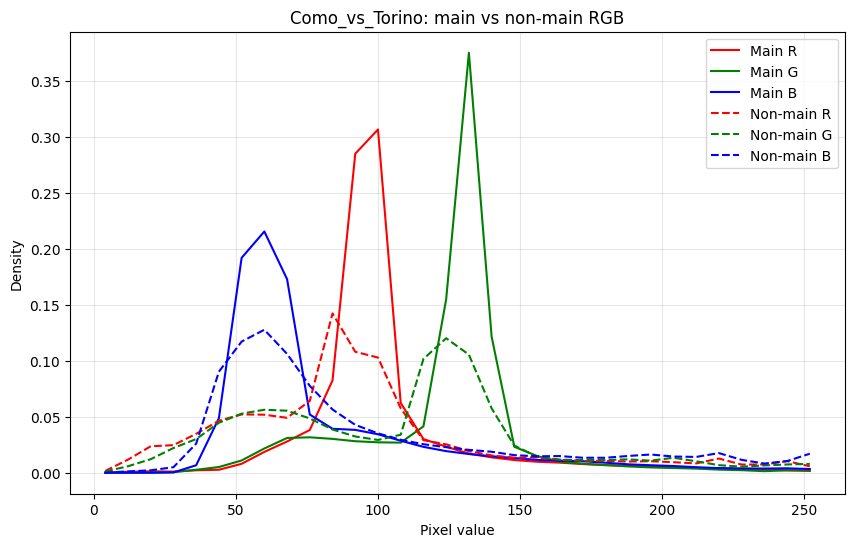

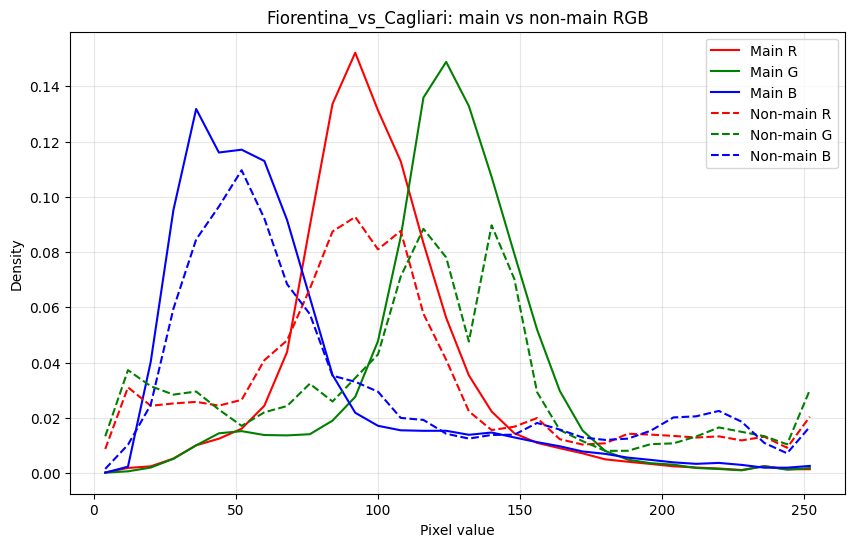

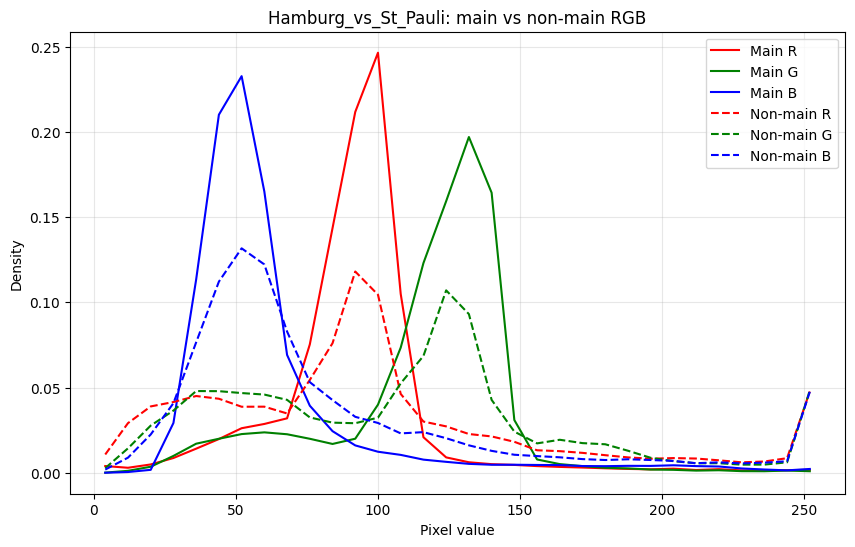

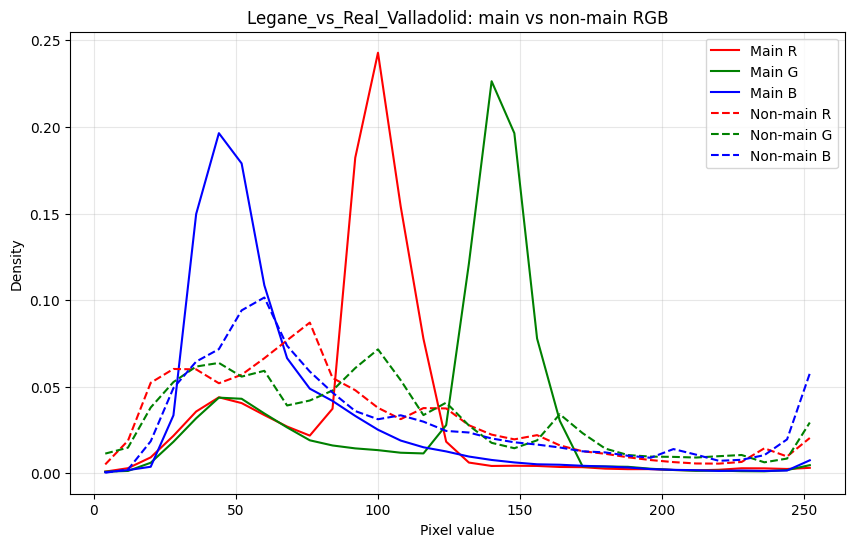

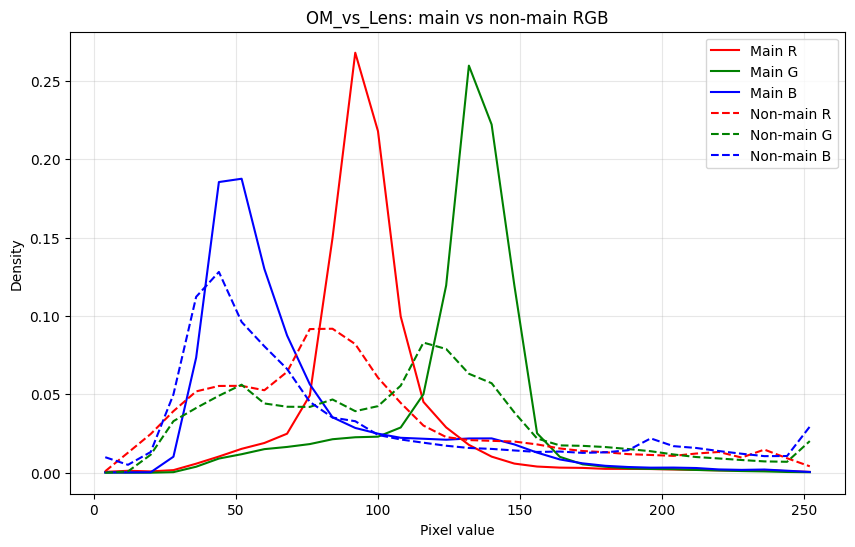

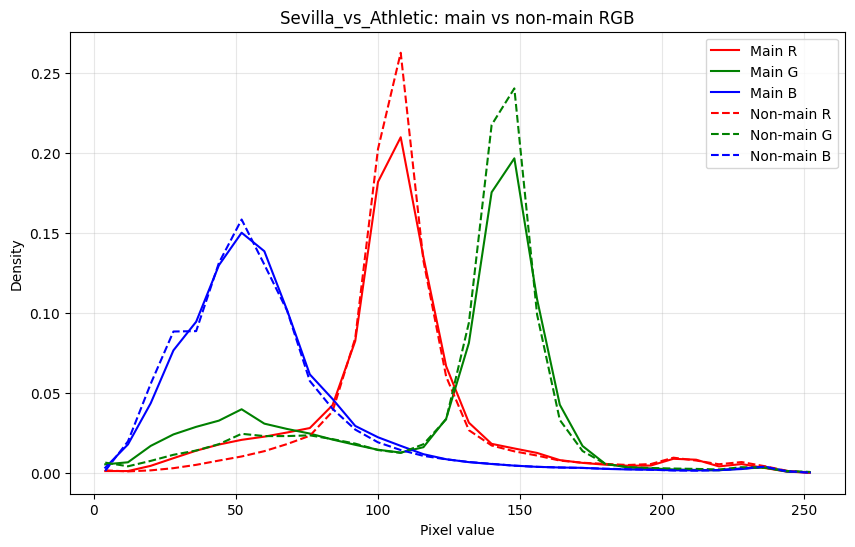

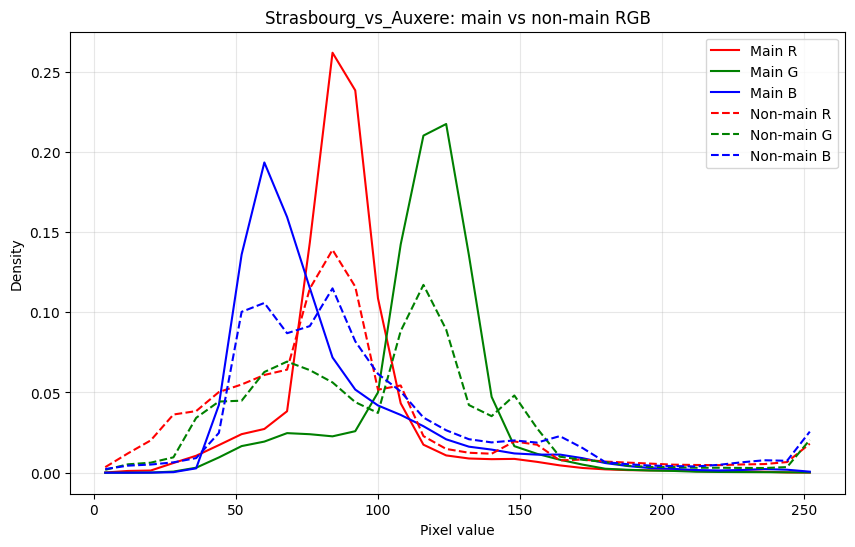

In [76]:
for match in match_main:
    plot_main_vs_nonmain_rgb(
        match_main[match],
        match_nonmain[match],
        bin_edges,
        title=f"{match}: main vs non-main RGB",
        normalize=True,
    )

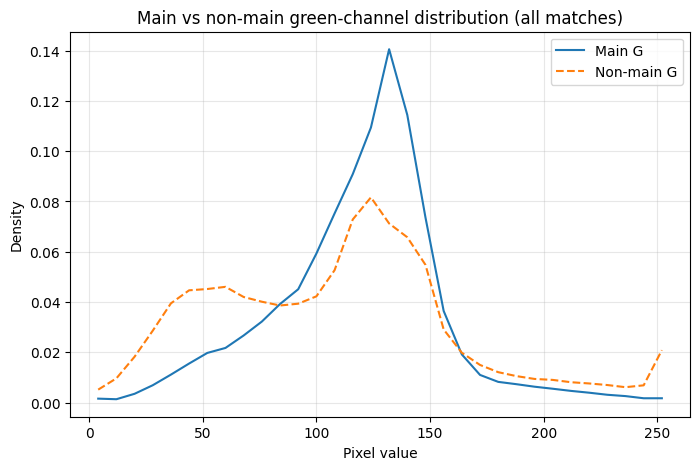

In [77]:
plot_main_vs_nonmain_single_channel(
    overall_main,
    overall_nonmain,
    bin_edges,
    channel="g",
    title="Main vs non-main green-channel distribution (all matches)",
    normalize=True,
)